In [1]:
# Generate simulated temperature readings from two sensors.
# Sensor A: mean 25 C, std 3 C, 200 readings.
# Sensor B: mean 27 C, std 4.5 C, 200 readings.
# Also generate 200 timestamps uniformly from 0 to 10 seconds.
# Use np.random.default_rng with a seed = 6411

import numpy as np
import matplotlib.pyplot as plt

# Reproducible random number generator for synthetic sensor noise
rng = np.random.default_rng(6411)

# Uniformly spaced timestamps from 0 to 10 seconds
timestamps = rng.uniform(low=0.0, high=10.0, size=200)

# Simulated temperature readings for two sensors
sensor_a = rng.normal(loc=25.0, scale=3.0, size=200)
sensor_b = rng.normal(loc=27.0, scale=4.5, size=200)

# Optional: preview the first few samples
sensor_a[:5], sensor_b[:5], timestamps[:5]

(array([26.01085005, 24.19274811, 21.84035899, 29.83778541, 24.57586483]),
 array([22.80976898, 27.03125676, 32.93333204, 28.03603847, 24.22997409]),
 array([4.92817791, 6.05255056, 5.13640562, 8.20109269, 8.21209515]))

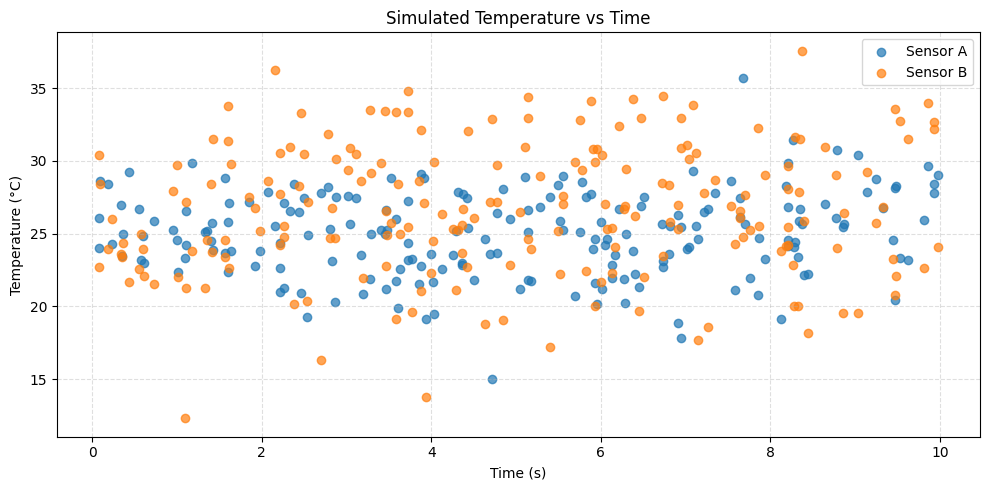

In [2]:
# Scatter plot: sensor reading (y-axis) vs timestamp in seconds (x-axis).
# Color Sensor A points blue and Sensor B points orange.
# Add axis labels with units, a title, and a legend.

plt.figure(figsize=(10, 5))
plt.scatter(timestamps, sensor_a, color="tab:blue", alpha=0.7, label="Sensor A")
plt.scatter(timestamps, sensor_b, color="tab:orange", alpha=0.7, label="Sensor B")

plt.title("Simulated Temperature vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

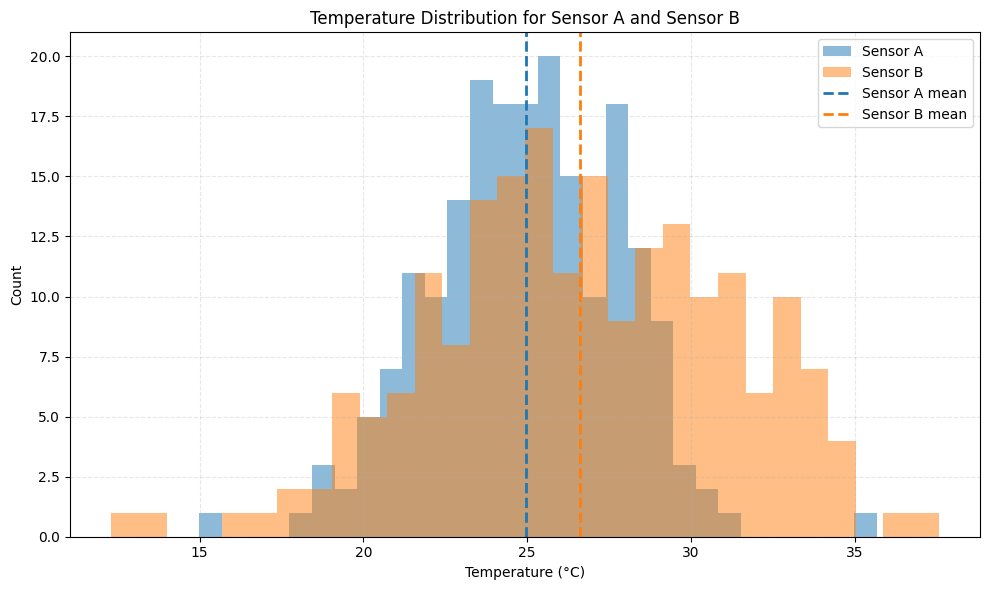

In [3]:
# Overlaid histogram of Sensor A and Sensor B temperature distributions.
# Use 30 bins, alpha=0.5 for transparency so both distributions are visible.
# Add vertical dashed lines at each sensor's mean.
# Include a legend labeling each sensor.

plt.figure(figsize=(10, 6))
plt.hist(sensor_a, bins=30, alpha=0.5, color="tab:blue", label="Sensor A")
plt.hist(sensor_b, bins=30, alpha=0.5, color="tab:orange", label="Sensor B")

mean_a = sensor_a.mean()
mean_b = sensor_b.mean()
plt.axvline(mean_a, color="tab:blue", linestyle="--", linewidth=2, label="Sensor A mean")
plt.axvline(mean_b, color="tab:orange", linestyle="--", linewidth=2, label="Sensor B mean")

plt.title("Temperature Distribution for Sensor A and Sensor B")
plt.xlabel("Temperature (°C)")
plt.ylabel("Count")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_5080/1609844572.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([sensor_a, sensor_b], labels=["Sensor A", "Sensor B"], patch_artist=True,


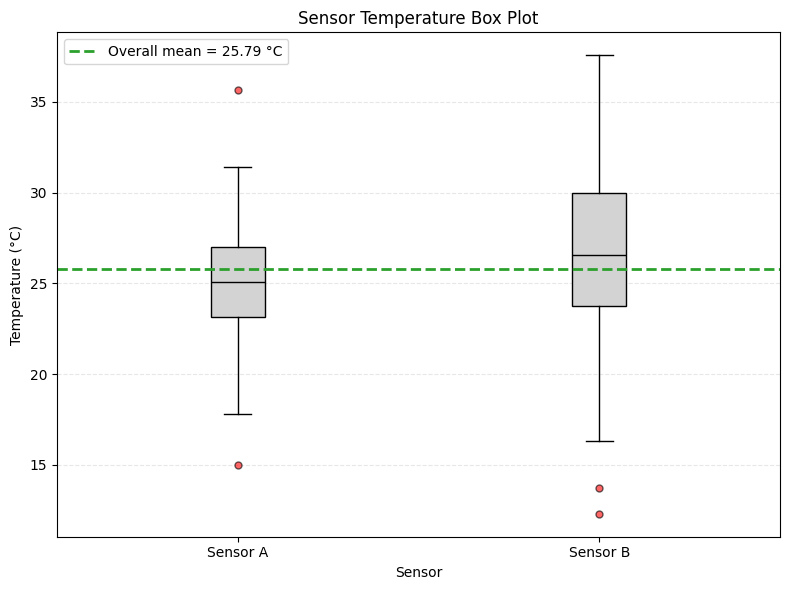

In [4]:
# Side-by-side box plot comparing Sensor A and Sensor B distributions.
# Label x-axis with sensor names, y-axis with "Temperature (deg C)".
# Add a horizontal dashed line at the overall mean of both sensors combined.

plt.figure(figsize=(8, 6))
plt.boxplot([sensor_a, sensor_b], labels=["Sensor A", "Sensor B"], patch_artist=True,
            boxprops=dict(facecolor="lightgrey", color="black"),
            medianprops=dict(color="black"),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
            flierprops=dict(marker="o", markerfacecolor="red", markersize=5, alpha=0.6))

overall_mean = np.concatenate([sensor_a, sensor_b]).mean()
plt.axhline(overall_mean, color="tab:green", linestyle="--", linewidth=2,
            label=f"Overall mean = {overall_mean:.2f} °C")

plt.title("Sensor Temperature Box Plot")
plt.xlabel("Sensor")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()